In [2]:
#importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns

## Loading crime data

In [3]:
#loading crime dataset
crime = pd.read_csv('crime_data.csv')
#printing the first few rows
crime.head()

/tmp/ipykernel_138/2149843072.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  crime = pd.read_csv('crime_data.csv')


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,...,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
0,201563066,9199,260006308,02/10/2026 07:42:38 PM,90Z,1,Crime Against Society,All Other Offenses,POLICE INFORMATION,SILVER SPRING,...,NaN,FIDLER,NaN,LA,02/10/2026 07:42:00 PM,NaN,38.99610,-77.0298,3D,POINT (-77.0298 38.9961)
1,201563057,9108,260006317,02/10/2026 07:06:31 PM,90Z,1,Crime Against Society,All Other Offenses,RECOVERED PROPERTY - MONT CO.,BETHESDA,...,NaN,EAST WEST,NaN,HWY,02/10/2026 07:06:00 PM,NaN,38.98865,-77.0735,2D,POINT (-77.0735 38.9887)
2,201563043,9109,260006301,02/10/2026 06:55:48 PM,90Z,1,Crime Against Society,All Other Offenses,RECOVERED PROPERTY - OTHER,TAKOMA PARK,...,NaN,NEW HAMPSHIRE,NaN,AVE,02/10/2026 06:55:00 PM,NaN,38.98337,-76.9883,TPPD,POINT (-76.9883 38.9834)
3,201563053,2308,260006298,02/10/2026 05:53:13 PM,23D,1,Crime Against Property,Theft from Building,LARCENY - FROM BLDG,BETHESDA,...,NaN,NICHOLSON,NaN,LA,02/10/2026 05:53:00 PM,NaN,39.04554,-77.1048,2D,POINT (-77.1048 39.0455)
4,201563053,3550,260006298,02/10/2026 05:53:13 PM,35B,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,BETHESDA,...,NaN,NICHOLSON,NaN,LA,02/10/2026 05:53:00 PM,NaN,39.04554,-77.1048,2D,POINT (-77.1048 39.0455)


In [4]:
crime['Crime Name1'].value_counts()

Crime Name1
Crime Against Property       163202
Crime Against Society        112529
Crime Against Person          35538
Crime Against Not a Crime      3963
Name: count, dtype: int64

In [5]:
crime['Crime Name1'] = crime['Crime Name1'].replace('Crime Against Not a Crime', 'Crime Against Property')

In [6]:
crime['Crime Name1'].value_counts()

Crime Name1
Crime Against Property    167165
Crime Against Society     112529
Crime Against Person       35538
Name: count, dtype: int64

In [7]:
crime.groupby('Police District Number')['Police District Name'].unique()

Police District Number
1D                  [ROCKVILLE]
2D                   [BETHESDA]
3D              [SILVER SPRING]
4D                    [WHEATON]
5D                 [GERMANTOWN]
6D         [MONTGOMERY VILLAGE]
TPPD              [TAKOMA PARK]
Unknown            [nan, OTHER]
Name: Police District Name, dtype: object

In [8]:
pd.DataFrame(crime.groupby(['Police District Number','Police District Name'])['City'].unique())

,,City
Police District Number,Police District Name,
1D,ROCKVILLE,"[POOLESVILLE, ROCKVILLE, POTOMAC, DERWOOD, GAI..."
2D,BETHESDA,"[CHEVY CHASE, KENSINGTON, CABIN JOHN, BETHESDA..."
3D,SILVER SPRING,"[SILVER SPRING, BURTONSVILLE, TAKOMA PARK, BEL..."
4D,WHEATON,"[SILVER SPRING, ROCKVILLE, OLNEY, KENSINGTON, ..."
5D,GERMANTOWN,"[GERMANTOWN, GAITHERSBURG, CLARKSBURG, DAMASCU..."
6D,MONTGOMERY VILLAGE,"[GAITHERSBURG, ROCKVILLE, MONTGOMERY VILLAGE, ..."
TPPD,TAKOMA PARK,"[TAKOMA PARK, SILVER SPRING, TACOMA PARK]"
Unknown,OTHER,"[NORTH POTOMAC, GAITHERSBURG, ROCKVILLE, SILVE..."


In [9]:
crime.to_csv('new_crime.csv', index=False)

In [10]:
#checking the dimension
crime.shape

(315232, 30)

In [11]:
#checking data types 

crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315232 entries, 0 to 315231
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             315232 non-null  int64  
 1   Offence Code            315232 non-null  object 
 2   CR Number               315232 non-null  int64  
 3   Dispatch Date / Time    315232 non-null  object 
 4   NIBRS Code              315232 non-null  object 
 5   Victims                 315232 non-null  int64  
 6   Crime Name1             315232 non-null  object 
 7   Crime Name2             315232 non-null  object 
 8   Crime Name3             315232 non-null  object 
 9   Police District Name    313937 non-null  object 
 10  Block Address           291272 non-null  object 
 11  City                    315212 non-null  object 
 12  State                   308838 non-null  object 
 13  Zip Code                315007 non-null  float64
 14  Agency              

In [12]:
#checking missing values
crime.isna().sum()

Incident ID                    0
Offence Code                   0
CR Number                      0
Dispatch Date / Time           0
NIBRS Code                     0
Victims                        0
Crime Name1                    0
Crime Name2                    0
Crime Name3                    0
Police District Name        1295
Block Address              23960
City                          20
State                       6394
Zip Code                     225
Agency                         0
Place                          0
Sector                         0
Beat                           0
PRA                            1
Address Number             23866
Street Prefix             300994
Street Name                 1225
Street Suffix             311646
Street Type                 1325
Start_Date_Time                0
End_Date_Time             179091
Latitude                       0
Longitude                      0
Police District Number         0
Location                       0
dtype: int

In [13]:
crime['Zip Code'].fillna(crime['Zip Code'].mode()[0], inplace=True)

crime['Police District Name'].fillna(crime['Police District Name'].mode()[0], inplace=True)

/tmp/ipykernel_138/559611298.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crime['Zip Code'].fillna(crime['Zip Code'].mode()[0], inplace=True)
/tmp/ipykernel_138/559611298.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [14]:
#converting zipcode to an int 
crime['Zip Code']=crime['Zip Code'].astype('int')

In [15]:
#subsetting the data to retain only important variables 

subset1 = crime[['Zip Code', 'Latitude', 'Longitude','Location', 'Police District Name','Police District Number', 'Start_Date_Time', "Victims"]]
subset1.head()

,Zip Code,Latitude,Longitude,Location,Police District Name,Police District Number,Start_Date_Time,Victims
0,20910,38.99610,-77.0298,POINT (-77.0298 38.9961),SILVER SPRING,3D,02/10/2026 07:42:00 PM,1
1,20815,38.98865,-77.0735,POINT (-77.0735 38.9887),BETHESDA,2D,02/10/2026 07:06:00 PM,1
2,20912,38.98337,-76.9883,POINT (-76.9883 38.9834),TAKOMA PARK,TPPD,02/10/2026 06:55:00 PM,1
3,20895,39.04554,-77.1048,POINT (-77.1048 39.0455),BETHESDA,2D,02/10/2026 05:53:00 PM,1
4,20895,39.04554,-77.1048,POINT (-77.1048 39.0455),BETHESDA,2D,02/10/2026 05:53:00 PM,1


In [16]:
#checking for duplicates 
subset1.duplicated().sum()
subset1 = subset1.drop_duplicates()

## Loading population and income data

In [17]:
#Loading income and population data 
pop_inc = pd.read_csv('census_data.csv')
pop_inc

,Year,District,Income,Population
0,2019,District 1,"131,588","21,993"
1,2020,District 1,"139,693","22,690"
2,2021,District 1,"140,270","22,672"
3,2022,District 1,"146,250","22,114"
4,2023,District 1,"154,606","22,225"
...,...,...,...,...
73,2020,District 13,"92,037","269,691"
74,2021,District 13,"97,901","272,874"
75,2022,District 13,"104,294","273,232"
76,2023,District 13,"108,229","272,679"


In [18]:
#converting Year as an integer
pop_inc['Year'].astype(int)
#converting income as an integer
pop_inc["Income"] = (
    pop_inc["Income"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [19]:
#converting population as an integer
pop_inc["Population"] = (
    pop_inc["Population"]
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [20]:
crosswalk = {
    'District 1': '5D',
    'District 2': '5D', 
    'District 3': '1D',
    'District 4': '1D', 
   'District 5': '3D', 
    'District 6': '1D',
    'District 7': '2D', 
    'District 8': '4D',
   'District 9': '6D',
    'District 10': '2D',
    'District 11': '5D', 
    'District 12': '5D',
    'District 13': '4D'
}

#Map the 13 districts to the 6 districts
pop_inc['Police_District'] = pop_inc['District'].map(crosswalk)

pop_inc

,Year,District,Income,Population,Police_District
0,2019,District 1,131588,21993,5D
1,2020,District 1,139693,22690,5D
2,2021,District 1,140270,22672,5D
3,2022,District 1,146250,22114,5D
4,2023,District 1,154606,22225,5D
...,...,...,...,...,...
73,2020,District 13,92037,269691,4D
74,2021,District 13,97901,272874,4D
75,2022,District 13,104294,273232,4D
76,2023,District 13,108229,272679,4D


/tmp/ipykernel_138/3719795427.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = subset1.resample('M').size()


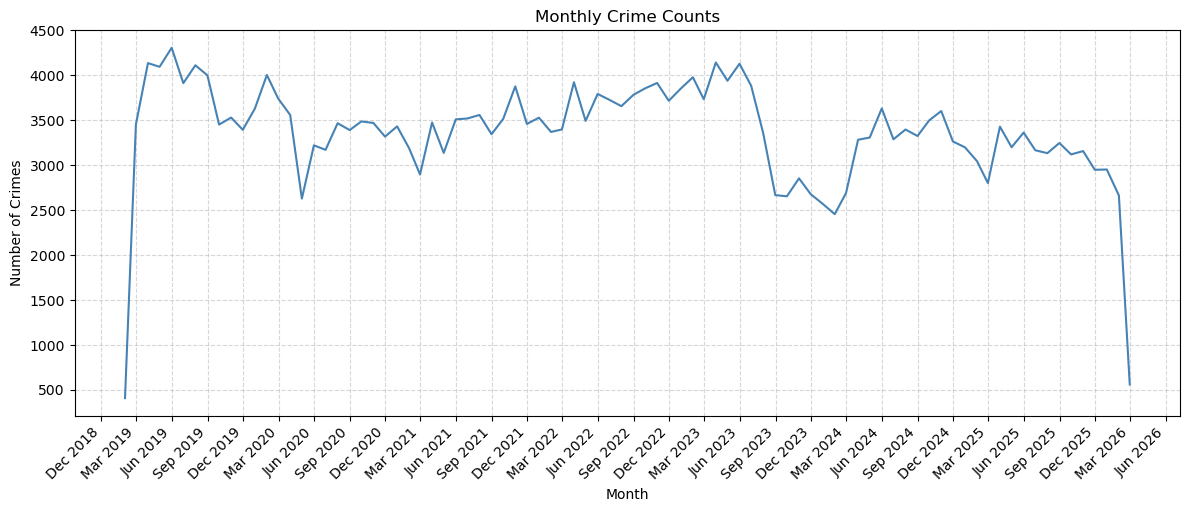

In [21]:
#converting crime dates to an actual datetime object 
subset1['Start_Date_Time'] = pd.to_datetime(subset1['Start_Date_Time'], format='%m/%d/%Y %I:%M:%S %p')
#sorting the values
subset1 = subset1.sort_values('Start_Date_Time')
#setting the dates as index
subset1.set_index('Start_Date_Time', inplace=True)
#dividing by month 
monthly_counts = subset1.resample('M').size()
#excluding any dates before 2019
monthly_counts = monthly_counts[monthly_counts.index>='2019-01-01']

#plotting
plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, linewidth=1.5, color='steelblue')
plt.title("Monthly Crime Counts")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.show()

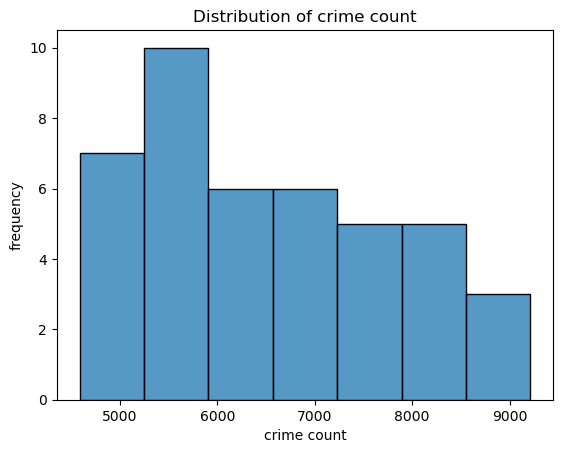

In [22]:
crime_per_year = subset1.groupby(subset1.index.year)['Police District Number'].value_counts().reset_index()
crime_per_year = crime_per_year[(crime_per_year['Police District Number']!='TPPD') & (crime_per_year['Police District Number']!='Unknown') & (crime_per_year['Start_Date_Time']>=2019) & (crime_per_year['Start_Date_Time']<2026)]

sns.histplot(crime_per_year['count'])
plt.xlabel('crime count')
plt.ylabel('frequency')
plt.title('Distribution of crime count')
plt.show()

In [23]:
subset2 = subset1[['Police District Number', 'Victims']]
subset2['Year'] = subset1.index.year
subset2.reset_index()

subset2= subset2[(subset2['Police District Number']!='TPPD') & (subset2['Police District Number']!='Unknown') & (subset2['Year']>=2019) & (subset2['Year']<2025)]


subs = subset2.groupby('Year')['Police District Number'].value_counts().reset_index().sort_values('Year')

/tmp/ipykernel_138/3840451289.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset2['Year'] = subset1.index.year


In [24]:
dist_inc = pop_inc.groupby(['Year', 'Police_District'])['Income'].median().reset_index()

dist_pop = pop_inc.groupby(['Year', 'Police_District'])['Population'].sum().reset_index()

new_popinc = pd.merge(dist_inc, dist_pop, on=['Year', 'Police_District'])
new_popinc = new_popinc.rename(columns={'Police_District': 'Police District Number'})
new_popinc.head()

,Year,Police District Number,Income,Population
0,2019,1D,160313.0,186312
1,2019,2D,190984.5,137746
2,2019,3D,93411.0,112057
3,2019,4D,118226.5,319313
4,2019,5D,124166.5,104144


In [25]:
df = pd.merge(new_popinc, subs, on=['Year', 'Police District Number'])
df = df.rename(columns={'count':"Crime Count"})
df['Crime_rate_per_1000'] = (df['Crime Count']/df['Population'])*1000
df.head()


,Year,Police District Number,Income,Population,Crime Count,Crime_rate_per_1000
0,2019,1D,160313.0,186312,5734,30.776332
1,2019,2D,190984.5,137746,5997,43.536654
2,2019,3D,93411.0,112057,9214,82.226010
3,2019,4D,118226.5,319313,8043,25.188451
4,2019,5D,124166.5,104144,5066,48.644185


/tmp/ipykernel_138/4080167485.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(x='Year', y='Income', data=df, hue='Police District Number', palette='Set2', ci=False, marker='o')


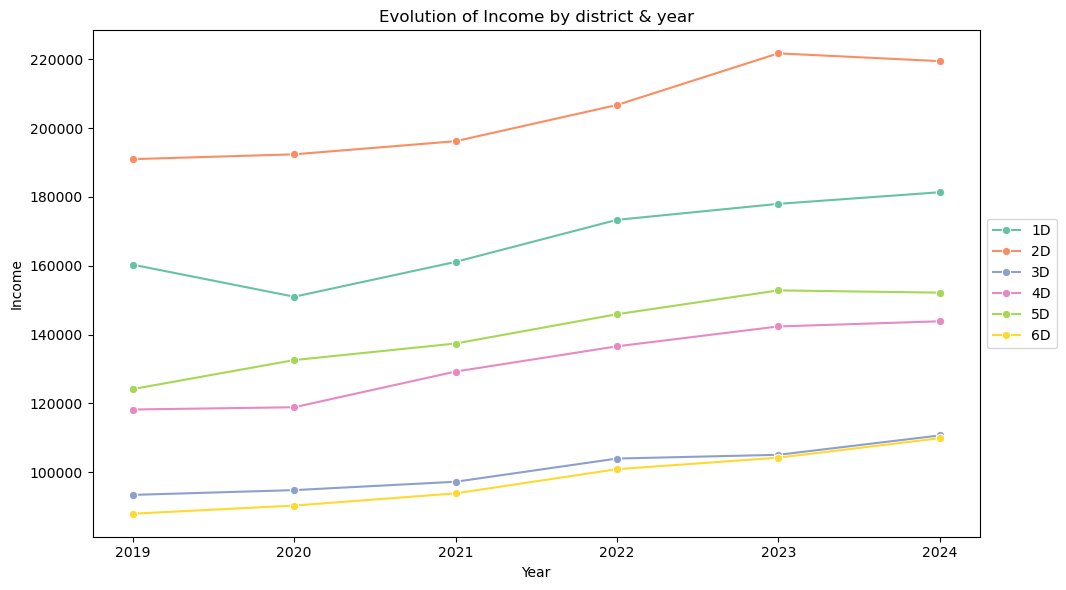

In [26]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='Income', data=df, hue='Police District Number', palette='Set2', ci=False, marker='o')
plt.title('Evolution of Income by district & year')
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

/tmp/ipykernel_138/929020286.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(x='Year', y='Population', data=df, hue='Police District Number', palette='Set2', ci=False, marker='o')


Text(0.5, 1.0, 'Evolution of Population by district & year')

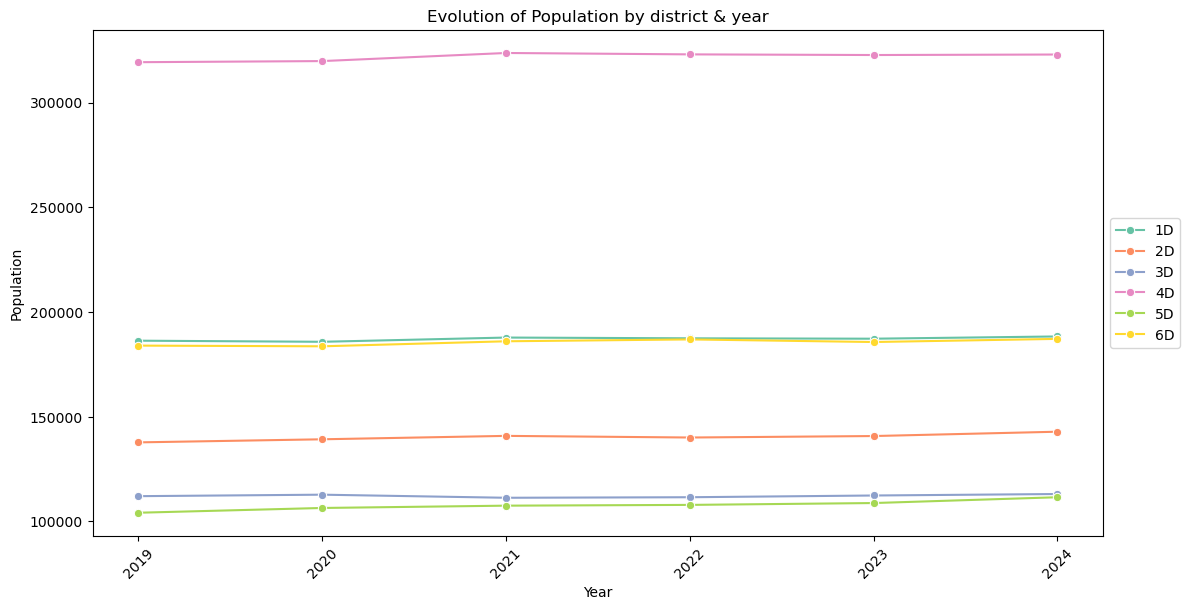

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Population', data=df, hue='Police District Number', palette='Set2', ci=False, marker='o')
plt.xticks(rotation=45)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.title('Evolution of Population by district & year')

/tmp/ipykernel_138/747175249.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(x='Year', y='Crime_rate_per_1000', data=df, hue='Police District Number', marker='o', ci=False)


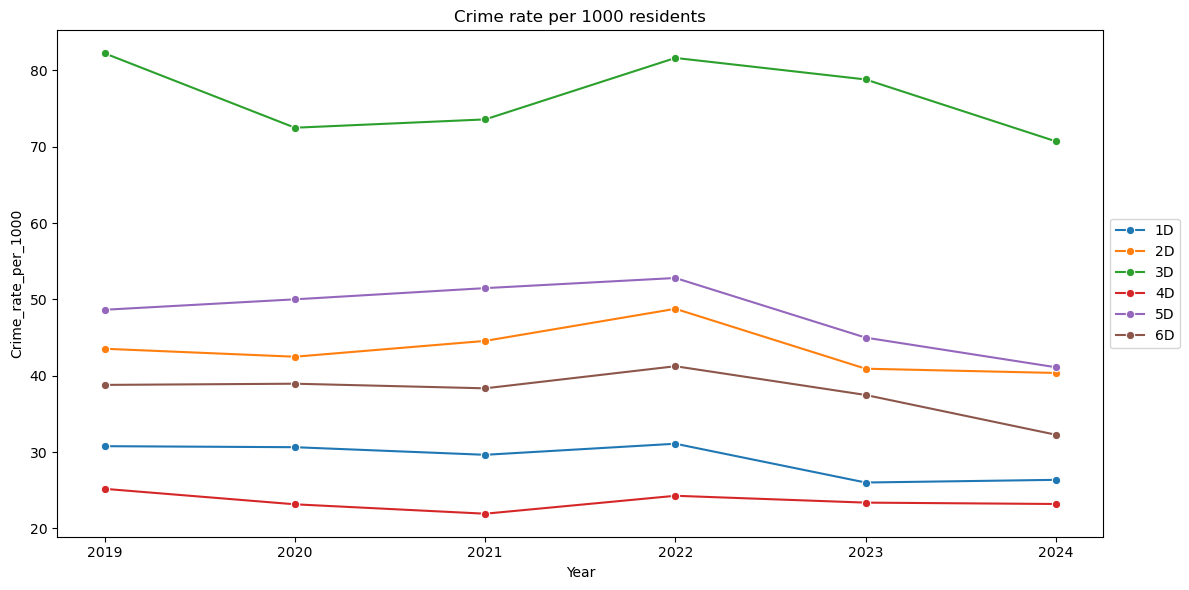

In [28]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Crime_rate_per_1000', data=df, hue='Police District Number', marker='o', ci=False)
plt.xlabel('Year')
plt.title('Crime rate per 1000 residents')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

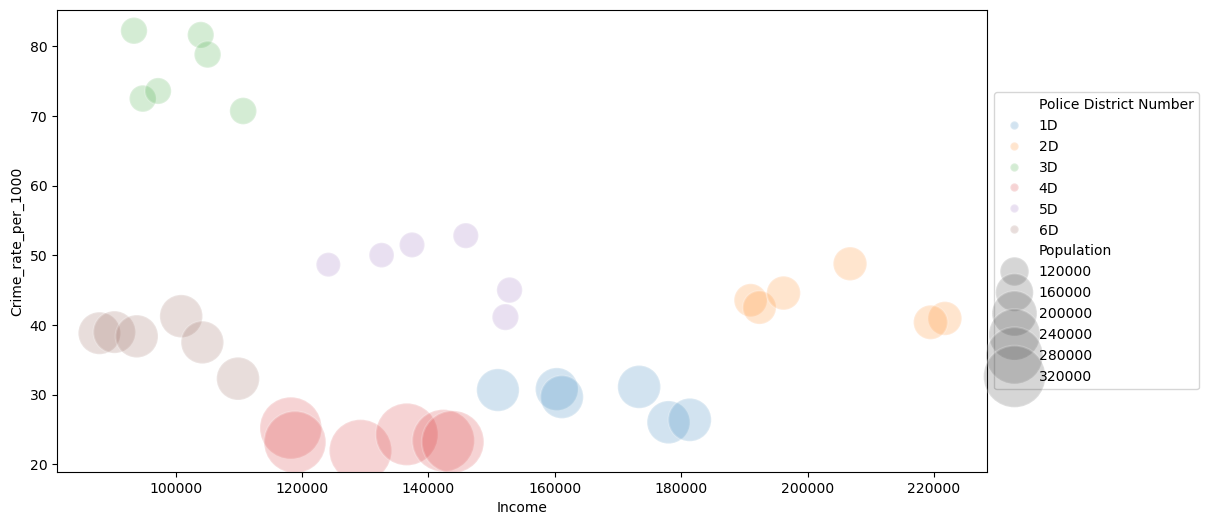

In [29]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x='Income',
    y='Crime_rate_per_1000',
    size="Population",
    hue='Police District Number',
    sizes=(300,2000),
    alpha=0.2,
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Inferential analysis

Ho : Income and population have no relationship with crime rate
Ha :  Income and population have a relationship with crime rate

In [30]:
#spearman correlation 

from scipy import stats


income_relation = stats.spearmanr(df['Crime_rate_per_1000'], df['Income'])

print(income_relation)

SignificanceResult(statistic=-0.21132561132561134, pvalue=0.21599953318319273)


In [31]:
#correlation matrix 

corr_matrix, p_matrix = stats.spearmanr(df[['Crime_rate_per_1000', 'Income', 'Population']])


print(f'Correlation matrix: \n{pd.DataFrame(corr_matrix, index=['Crime_rate_per_1000', 'Income', 'Population'], 
                                         columns=['Crime_rate_per_1000', 'Income', 'Population'])}')

Correlation matrix: 
                     Crime_rate_per_1000    Income  Population
Crime_rate_per_1000             1.000000 -0.211326   -0.901673
Income                         -0.211326  1.000000    0.085199
Population                     -0.901673  0.085199    1.000000


In [32]:
print(f'P-values matrix: \n{pd.DataFrame(p_matrix, index=['Crime_rate_per_1000', 'Income', 'Population'], columns=['Crime_rate_per_1000', 'Income', 'Population'])}')

P-values matrix: 
                     Crime_rate_per_1000    Income    Population
Crime_rate_per_1000         0.000000e+00  0.216000  6.251207e-14
Income                      2.159995e-01  0.000000  6.212667e-01
Population                  6.251207e-14  0.621267  0.000000e+00


### linear model

In [33]:
import statsmodels.formula.api as sm

In [34]:
model = sm.ols("Crime_rate_per_1000 ~ Income + Population", data=df).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Crime_rate_per_1000   R-squared:                       0.694
Model:                             OLS   Adj. R-squared:                  0.676
Method:                  Least Squares   F-statistic:                     37.48
Date:                 Sat, 09 May 2026   Prob (F-statistic):           3.21e-09
Time:                         12:34:43   Log-Likelihood:                -132.52
No. Observations:                   36   AIC:                             271.0
Df Residuals:                       33   BIC:                             275.8
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     99.9574      7.750     12.89